In [2]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion","fargo_fiducial_closer_companion",  
             "fargo_fiducial_2gen",]

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [4]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

rho_mean = np.mean(rho_cube, axis=3)

/scratch/2357027/ipykernel_1520029/4133985318.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[-1][-1]),cmap=cm.Oranges_r)


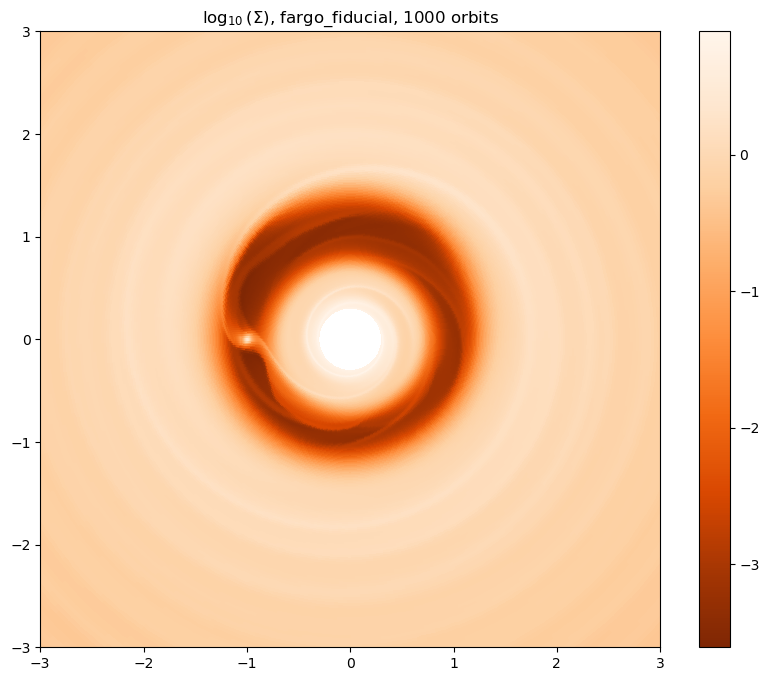

In [5]:
## make this a round plot so I know what's going on.

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

X = R*np.cos(PHI)
Y = R*np.sin(PHI)

plt.figure(figsize=(10,8))
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.pcolormesh(X, Y,np.log10(rho_cube[-1][-1]),cmap=cm.Oranges_r)
plt.title(f"$\\log_{{10}} \\left(\\Sigma\\right)$, {paths[-1][43:-5]}, {(frames[-1])*10} orbits")
plt.colorbar()

# Ignore

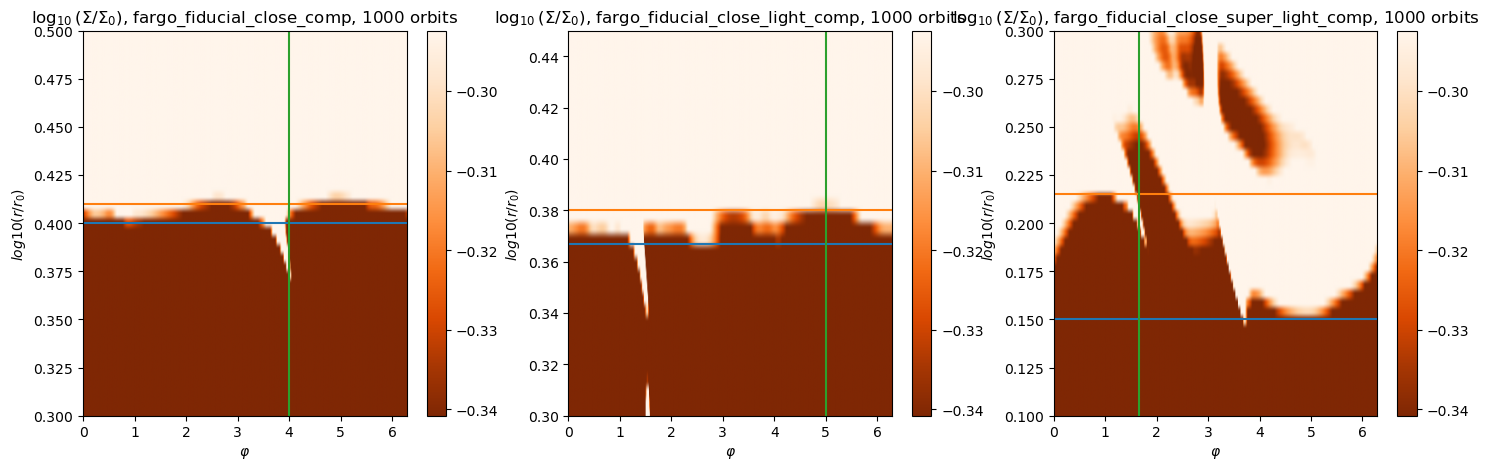

In [6]:
%matplotlib inline
r_min = 0.3
r_max = 7

#### careful, reversed order . . . ######
index_for_comp_close=[4,5,7]

r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]

ylim_lower = [0.3,0.3,0.1]
ylim_upper = [0.5,0.45,0.3]

plt.figure(figsize=(24,5))
frame = 100

for it,i in enumerate(index_for_comp_close):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(ylim_lower[it], ylim_upper[it])
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 2.51188643150958
r_out: 2.5703957827688635
Eccentricity for fargo_fiducial_close_comp: 0.011512416822289791


/scratch/2351404/ipykernel_1382813/2359715410.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


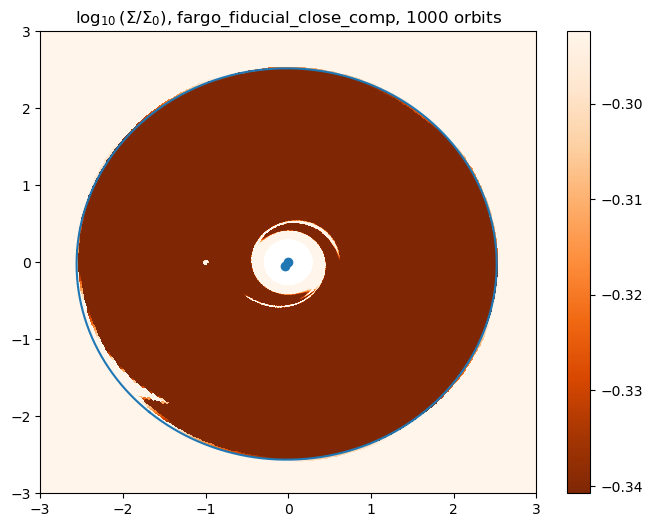

In [153]:

model_ind = [4,5,7][0]

"""
r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]
"""

r_in = np.power(10,0.4) # +- 0.005
r_out = np.power(10,0.41) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

r_in: 2.328091257665008
r_out: 2.3988329190194904
Eccentricity for fargo_fiducial_close_light_comp: 0.014965685657369903


/scratch/2351404/ipykernel_1382813/2410491833.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


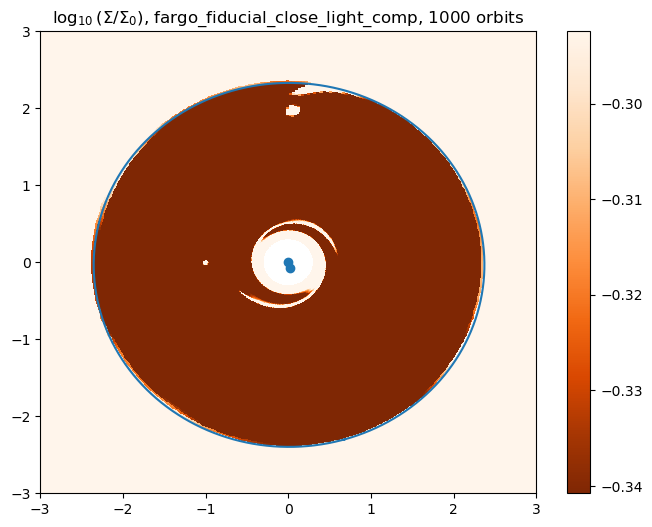

In [169]:

model_ind = [4,5,7][1]

"""
r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]
"""

r_in = np.power(10,0.367) # +- 0.005
r_out = np.power(10,0.38) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

r_in: 1.4125375446227544
r_out: 1.6405897731995394
Eccentricity for fargo_fiducial_close_super_light_comp: 0.07469463433298548


/scratch/2351404/ipykernel_1382813/626689000.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


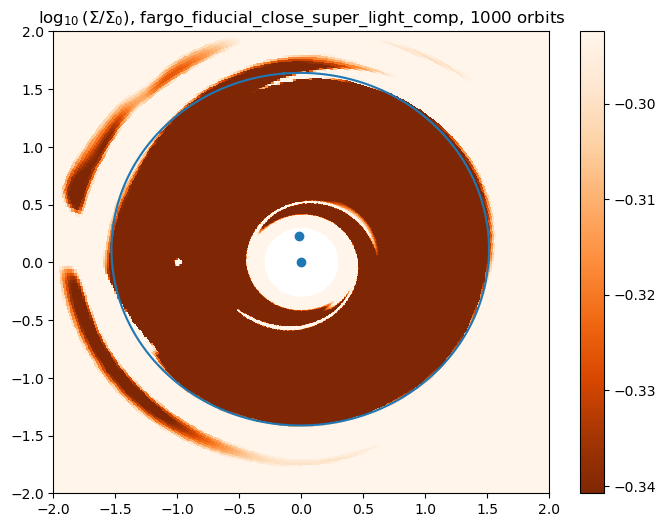

In [185]:

model_ind = [4,5,7][2]

"""
r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]

"""

r_in = np.power(10,0.15) # +- 0.01
r_out = np.power(10,0.215) # +- 0.01

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.8-np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.colorbar()

[0.011512416822289791+/-0.008139788711646298
 0.014965685657369903+/-0.008139044343220542
 0.07469463433298548+/-0.016190894838094497]


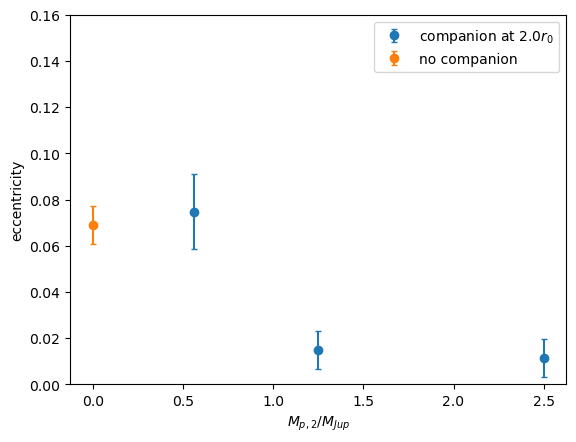

In [62]:

from uncertainties import ufloat
r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]

r_in_log = [ufloat(0.4,0.005),ufloat(0.367,0.005),ufloat(0.15,0.01)]
r_out_log = [ufloat(0.41,0.005),ufloat(0.38,0.005),ufloat(0.215,0.01)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([2.5,1.25,0.56],ecc_values, yerr = ecc_errs, fmt="o", capsize=2, label="companion at $2.0r_0$")
plt.xlabel("$M_{p,2}/M_{Jup}$")
plt.ylabel("eccentricity")
plt.ylim(0,0.16)


r_in_log_fid = ufloat(0.14,0.005)
r_out_log_fid = ufloat(0.20,0.005)



r_in = np.power(10,r_in_log_fid)
r_out = np.power(10, r_out_log_fid)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_value_fid  = ecc.nominal_value
ecc_err_fid= ecc.std_dev

plt.errorbar([0],[ecc_value_fid], yerr = [ecc_err_fid], fmt="o", capsize=2, label="no companion")
plt.legend()

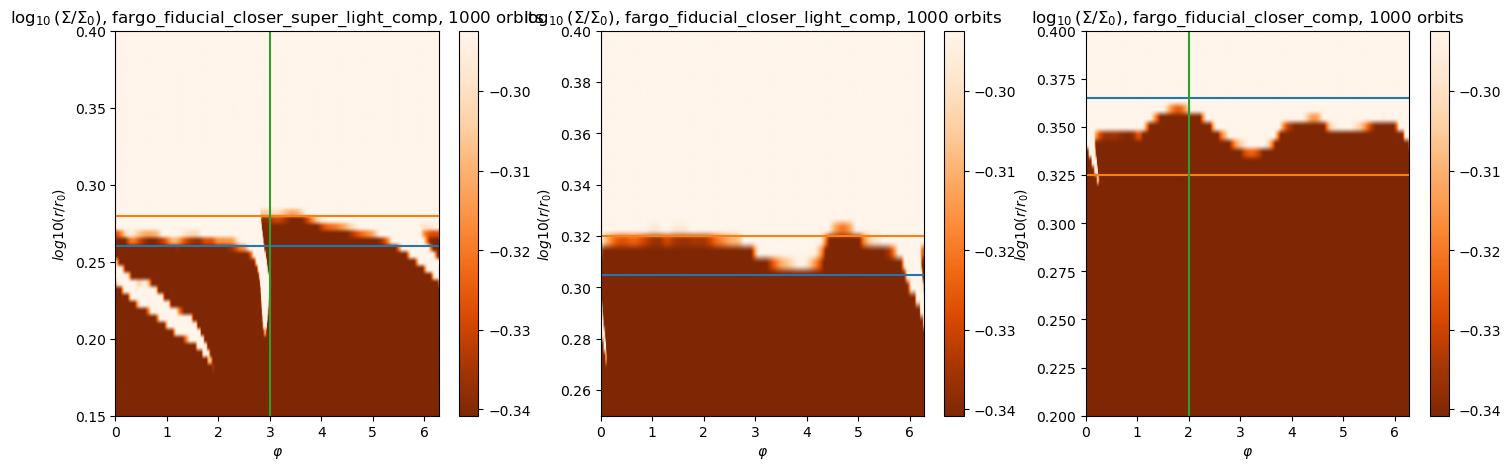

In [70]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_closer=[9,8,10]

r_in_log = [0.26,0.305,0.365]
r_out_log = [0.28,0.32,0.325]
phi_ellipse = [3,0,2]

ylim_lower = [0.15,0.25,0.2]
ylim_upper = [0.4,0.4,0.4]

plt.figure(figsize=(24,5))
frame = 100

for it,i in enumerate(index_for_closer):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(ylim_lower[it], ylim_upper[it])
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 1.8197008586099834
r_out: 1.9054607179632472
Eccentricity for fargo_fiducial_closer_super_light_comp: 0.023021782435583407


/scratch/2351404/ipykernel_1388081/2267816068.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


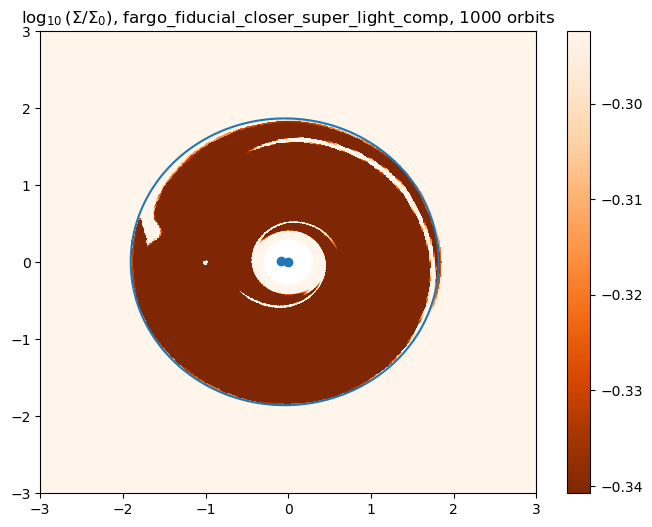

In [68]:

model_ind = [9,8,10][0]

r_in = np.power(10,0.26) # +- 0.005
r_out = np.power(10,0.28) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 3.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

r_in: 2.0183663636815607
r_out: 2.0892961308540396
Eccentricity for fargo_fiducial_closer_light_comp: 0.01726767164216543


/scratch/2351404/ipykernel_1388081/2515592791.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


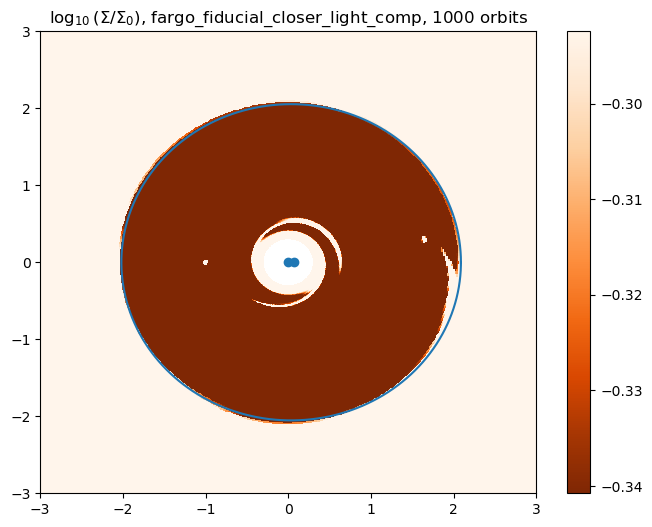

In [69]:

model_ind = [9,8,10][1]


r_in = np.power(10,0.305) # +- 0.005
r_out = np.power(10,0.32) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 0.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

r_in: 2.2130947096056377
r_out: 2.2490546058357808
Eccentricity for fargo_fiducial_closer_comp: 0.008058873356322395


/scratch/2351404/ipykernel_1388081/1347159489.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


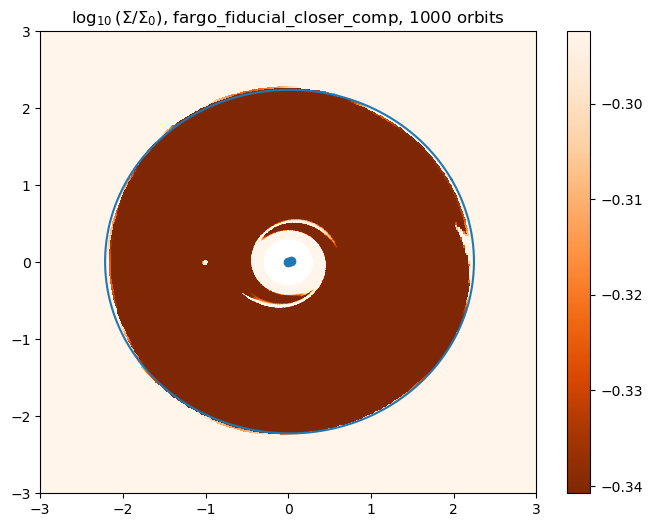

In [113]:

model_ind = [9,8,10][2]


r_in = np.power(10,0.345) # +- 0.005
r_out = np.power(10,0.352) # +- 0.005

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 0.5
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

[0.023021782435583407+/-0.008136552987632377
 0.01726767164216543+/-0.008138440284841853
 0.008058873356322395+/-0.008140338955344927]


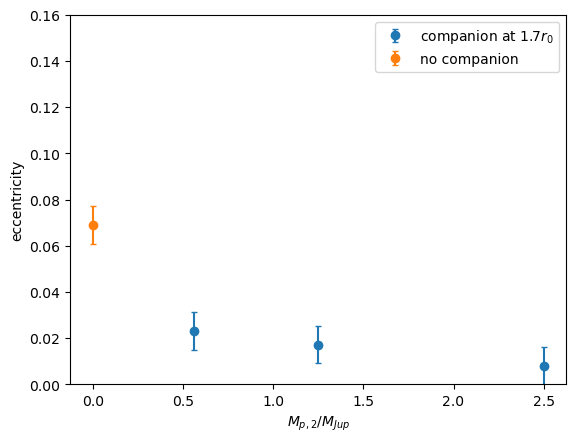

In [114]:

from uncertainties import ufloat

r_in_log = [ufloat(0.26,0.005),ufloat(0.305,0.005),ufloat(0.345, 0.005)]
r_out_log = [ufloat(0.28,0.005),ufloat(0.32,0.005), ufloat(0.352, 0.005)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([0.56,1.25,2.5],ecc_values, yerr = ecc_errs, fmt="o", capsize=2, label="companion at $1.7r_0$")
plt.xlabel("$M_{p,2}/M_{Jup}$")
plt.ylabel("eccentricity")
plt.ylim(0,0.16)


r_in_log_fid = ufloat(0.14,0.005)
r_out_log_fid = ufloat(0.20,0.005)



r_in = np.power(10,r_in_log_fid)
r_out = np.power(10, r_out_log_fid)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
ecc_value_fid  = ecc.nominal_value
ecc_err_fid= ecc.std_dev

plt.errorbar([0],[ecc_value_fid], yerr = [ecc_err_fid], fmt="o", capsize=2, label="no companion")
plt.legend()

# Stuff

[ 35 150]
[ 37 159 167 207]
[ 37 214]
[ 37 224]


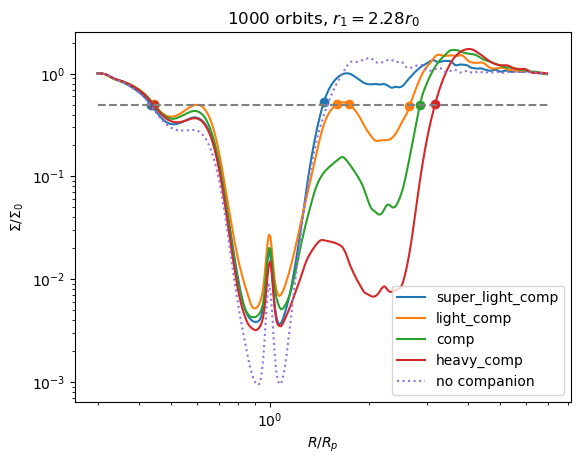

In [33]:
from uncertainties import ufloat
index_for_comp_mass=[1,2,0,3]
index_for_no_comp = 11
gap_width_norm = []
for i in index_for_comp_mass:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-0.5)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[58:-5]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[1], r_sign_err[1])
    gap_width_norm.append(r_right-r_left)

plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")
plt.plot(r_list,rho_mean[index_for_no_comp][-1]/rho_mean[index_for_no_comp][0], label=f"no companion", color="mediumpurple", linestyle="dotted")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits, $r_1 = 2.28r_0$")
plt.legend()
plt.savefig("img/dens_comp.PNG")

[ 35 156]
[ 36 196]
[ 36 203]


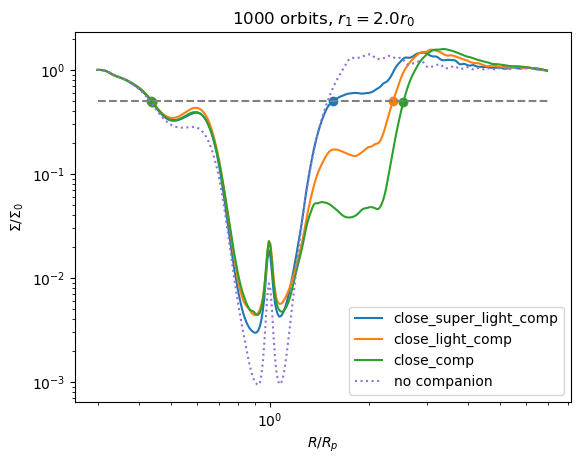

In [34]:
index_for_comp_close=[7,5,4]

gap_width_close = []
for i in index_for_comp_close:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-0.5)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[58:-5]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[-1], r_sign_err[-1])
    gap_width_close.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")
plt.plot(r_list,rho_mean[index_for_no_comp][-1]/rho_mean[index_for_no_comp][0], label=f"no companion", color="mediumpurple", linestyle="dotted")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits, $r_1 = 2.0r_0$")
plt.legend()
plt.savefig("img/dens_close_comp.PNG")

[ 35 172]
[ 36 183]
[ 37 191]


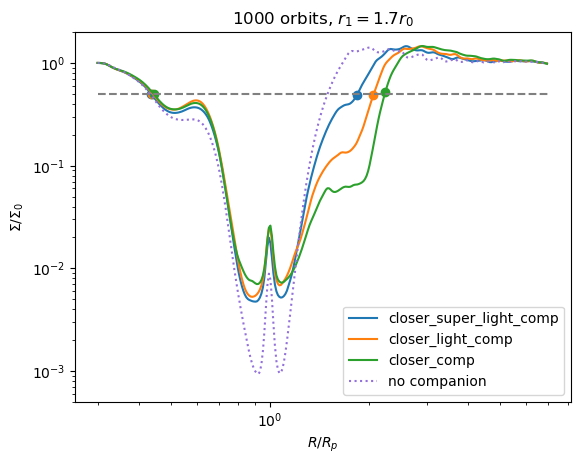

In [35]:
index_for_closer=[9,8,10]

gap_width_closer = []
for i in index_for_closer:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-0.5)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[58:-5]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[-1], r_sign_err[-1])
    gap_width_closer.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")
plt.plot(r_list,rho_mean[index_for_no_comp][-1]/rho_mean[index_for_no_comp][0], label=f"no companion", color="mediumpurple", linestyle="dotted")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits, $r_1 = 1.7r_0$")
plt.legend(loc="lower right")
plt.ylim(5e-4, 2)
plt.savefig("img/dens_closer_comp.PNG")

# Summary

In [36]:
def ufloat_arr(arr):
    values= [ee.nominal_value for ee in arr]
    errs = [ee.std_dev for ee in arr]
    return values, errs

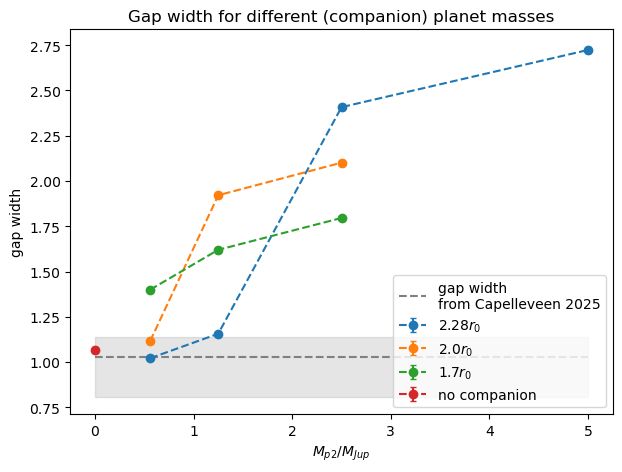

In [37]:
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
mjup = mstar*0.00177/2

r0 = 57
gap_obs_lower = 46.03/r0
gap_obs = 58.5/r0
gap_obs_upper = 64.86/r0

plt.figure(figsize=(7,5))

gap_norm_values , gap_norm_errs = ufloat_arr(gap_width_norm)
plt.errorbar([0.56,1.25,2.5,5],gap_norm_values, yerr = gap_norm_errs, fmt="o--", capsize=2, label="$2.28 r_0$")

gap_close_values , gap_close_errs = ufloat_arr(gap_width_close)
plt.errorbar([0.56,1.25,2.5,],gap_close_values, yerr = gap_close_errs, fmt="o--", capsize=2, label="$2.0 r_0$")

gap_closer_values , gap_closer_errs = ufloat_arr(gap_width_closer)
plt.errorbar([0.56,1.25,2.5,],gap_closer_values, yerr = gap_closer_errs, fmt="o--", capsize=2, label="$1.7 r_0$")

# no companion 1.068+/-0.016
plt.errorbar([0],[1.068], yerr=[0.016], fmt="o--", capsize=2, label="no companion")

#masses = np.linspace(2,10,100)
#gap_mass_pred = 0.41*np.sqrt(masses*mjup/mstar)*0.069**(-3/4)*(1e-3)**(-1/4)
#plt.plot(masses, gap_mass_pred, label="Kanagawa 2017")

plt.xlabel("$M_{p2}/M_{Jup}$")
plt.ylabel("gap width")
#plt.xscale("log")

plt.plot([0,5],[gap_obs,gap_obs], color="gray", linestyle="dashed", label="gap width \nfrom Capelleveen 2025")
plt.fill_between([0,5], gap_obs_lower,gap_obs_upper, alpha=0.2, color="gray")
plt.legend(loc="lower right")
#plt.ylim(0.6,1.35)
plt.title("Gap width for different (companion) planet masses")
plt.savefig("img/companion_gap_width.png")

# More stuff

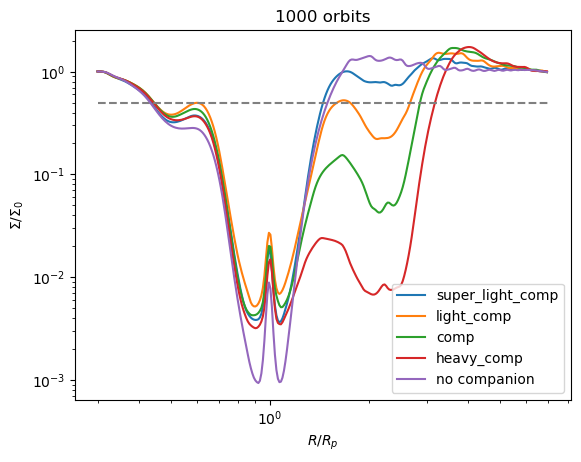

In [42]:
from uncertainties import ufloat
index_for_comp_mass=[1,2,0,3]

index_for_no_comp = 11

gap_width_norm = []
for i in index_for_comp_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[58:-5]}")

    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")
plt.plot(r_list,rho_mean[index_for_no_comp][-1]/rho_mean[index_for_no_comp][0], label=f"no companion")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

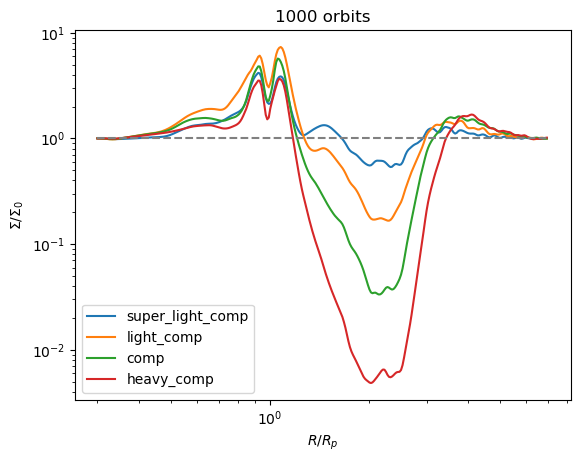

In [81]:
from uncertainties import ufloat
index_for_comp_mass=[1,2,0,3]

index_for_no_comp = 11

gap_width_norm = []
for i in index_for_comp_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[index_for_no_comp][-1], label=f"{path[58:-5]}")

    
plt.plot([0.3,7],[1,1], color="grey", linestyle="--")
#plt.plot(r_list,rho_mean[index_for_no_comp][-1]/rho_mean[index_for_no_comp][0], label=f"no companion")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

## lim =0.3

[ 72 146]
[ 76 149 178 200]
[ 74 211]
[ 72 220]


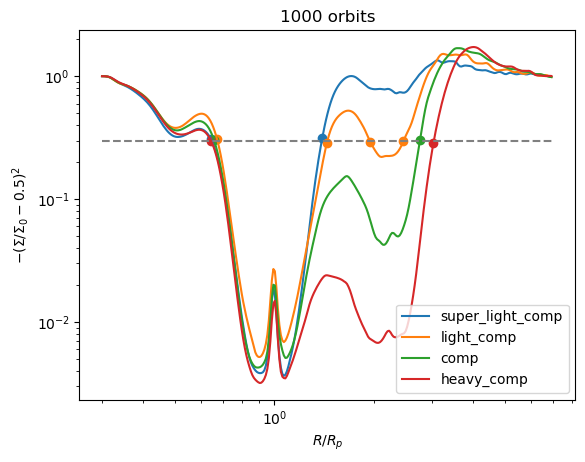

In [74]:
from uncertainties import ufloat
index_for_comp_mass=[1,2,0,3]

lim=0.3

gap_width_norm = []
gap_width_norm_sec =[]
for i in index_for_comp_mass:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-lim)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[58:-5]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[1], r_sign_err[1])
    gap_width_norm.append(r_right-r_left)

    if len(r_sign)>2:
        r_left = ufloat(r_sign[2], r_sign_err[2])
        r_right = ufloat(r_sign[3], r_sign_err[3])
        gap_width_norm_sec.append(r_right-r_left)
    else:
        gap_width_norm_sec.append(ufloat(-10,1))
    
plt.plot([0.3,7],[lim,lim], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$-(\\Sigma/\\Sigma_0 - 0.5)^2$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

[ 73 148]
[ 74 191]
[ 73 199]


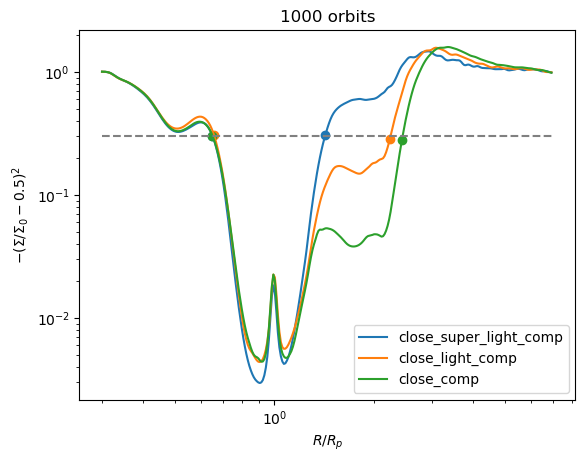

In [75]:
index_for_comp_close=[7,5,4]

gap_width_close = []
gap_width_close_sec = []
for i in index_for_comp_close:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-lim)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[58:-5]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[-1], r_sign_err[-1])
    gap_width_close.append(r_right-r_left)

    if len(r_sign)>2:
        r_left = ufloat(r_sign[2], r_sign_err[2])
        r_right = ufloat(r_sign[3], r_sign_err[3])
        gap_width_close_sec.append(r_right-r_left)
    else:
        gap_width_close_sec.append(ufloat(-10,1))
    
plt.plot([0.3,7],[lim,lim], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$-(\\Sigma/\\Sigma_0 - 0.5)^2$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

[ 73 156]
[ 74 178]
[ 74 187]


(0.003, 10)

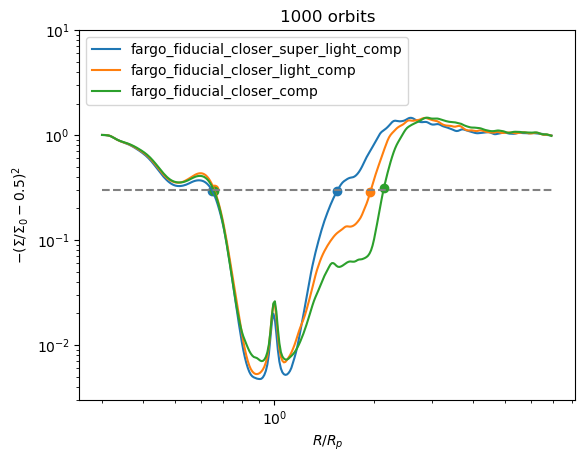

In [76]:
index_for_closer=[9,8,10]

gap_width_closer = []
gap_width_closer_sec = []
for i in index_for_closer:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-lim)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[-1], r_sign_err[-1])
    gap_width_closer.append(r_right-r_left)

    if len(r_sign)>2:
        r_left = ufloat(r_sign[2], r_sign_err[2])
        r_right = ufloat(r_sign[3], r_sign_err[3])
        gap_width_closer_sec.append(r_right-r_left)
    else:
        gap_width_closer_sec.append(ufloat(-10,1))
    
plt.plot([0.3,7],[lim,lim], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$-(\\Sigma/\\Sigma_0 - 0.5)^2$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper left")
plt.ylim(3e-3, 10)

[ 48 148]


(0.0005, 10)

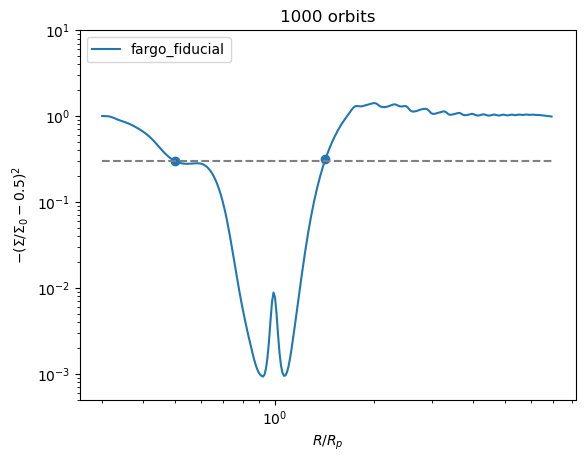

In [77]:
index_no_comp=[11]

gap_width_no = []
gap_width_no_sec = []
for i in index_no_comp:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-lim)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[-1], r_sign_err[-1])
    gap_width_no.append(r_right-r_left)

    if len(r_sign)>2:
        r_left = ufloat(r_sign[2], r_sign_err[2])
        r_right = ufloat(r_sign[3], r_sign_err[3])
        gap_width_no_sec.append(r_right-r_left)
    else:
        gap_width_no_sec.append(ufloat(-10,1))
    
plt.plot([0.3,7],[lim,lim], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$-(\\Sigma/\\Sigma_0 - 0.5)^2$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper left")
plt.ylim(5e-4, 10)

Text(0.5, 1.0, 'Gap width for different (companion) planet masses')

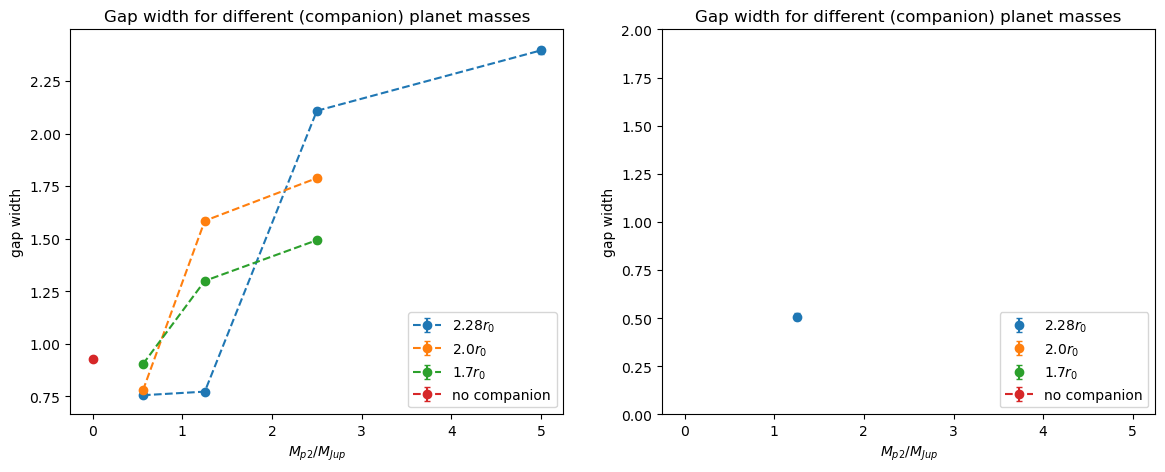

In [79]:
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
mjup = mstar*0.00177/2

r0 = 57
gap_obs_lower = 46.03/r0
gap_obs = 58.5/r0
gap_obs_upper = 64.86/r0

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
gap_norm_values , gap_norm_errs = ufloat_arr(gap_width_norm)
plt.errorbar([0.56,1.25,2.5,5],gap_norm_values, yerr = gap_norm_errs, fmt="o--", capsize=2, label="$2.28 r_0$")

gap_close_values , gap_close_errs = ufloat_arr(gap_width_close)
plt.errorbar([0.56,1.25,2.5,],gap_close_values, yerr = gap_close_errs, fmt="o--", capsize=2, label="$2.0 r_0$")

gap_closer_values , gap_closer_errs = ufloat_arr(gap_width_closer)
plt.errorbar([0.56,1.25,2.5,],gap_closer_values, yerr = gap_closer_errs, fmt="o--", capsize=2, label="$1.7 r_0$")

gap_no_values, gap_no_errs = ufloat_arr(gap_width_no)
# no companion 1.068+/-0.016
plt.errorbar([0],gap_no_values, yerr=gap_no_errs, fmt="o--", capsize=2, label="no companion")

#masses = np.linspace(2,10,100)
#gap_mass_pred = 0.41*np.sqrt(masses*mjup/mstar)*0.069**(-3/4)*(1e-3)**(-1/4)
#plt.plot(masses, gap_mass_pred, label="Kanagawa 2017")

plt.xlabel("$M_{p2}/M_{Jup}$")
plt.ylabel("gap width")
#plt.xscale("log")

#plt.plot([0,5],[gap_obs,gap_obs], color="gray", linestyle="dashed", label="gap width \nfrom Capelleveen 2025")
#plt.fill_between([0,5], gap_obs_lower,gap_obs_upper, alpha=0.2, color="gray")
plt.legend(loc="lower right")
#plt.ylim(0.6,1.35)
plt.title("Gap width for different (companion) planet masses")

plt.subplot(1,2,2)

gap_norm_values , gap_norm_errs = ufloat_arr(gap_width_norm_sec)
plt.errorbar([0.56,1.25,2.5,5],gap_norm_values, yerr = gap_norm_errs, fmt="o", capsize=2, label="$2.28 r_0$")

gap_close_values , gap_close_errs = ufloat_arr(gap_width_close_sec)
plt.errorbar([0.56,1.25,2.5,],gap_close_values, yerr = gap_close_errs, fmt="o", capsize=2, label="$2.0 r_0$")

gap_closer_values , gap_closer_errs = ufloat_arr(gap_width_closer_sec)
plt.errorbar([0.56,1.25,2.5,],gap_closer_values, yerr = gap_closer_errs, fmt="o", capsize=2, label="$1.7 r_0$")
plt.ylim(0,2)

gap_no_values, gap_no_errs = ufloat_arr(gap_width_no_sec)
# no companion 1.068+/-0.016
plt.errorbar([0],gap_no_values, yerr=gap_no_errs, fmt="o--", capsize=2, label="no companion")

plt.xlabel("$M_{p2}/M_{Jup}$")
plt.ylabel("gap width")
plt.legend(loc="lower right")
plt.title("Gap width for different (companion) planet masses")

#plt.savefig("img/companion_gap_width.png")